# 48.1 · Rays, density and positional encoding

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain rays, density and positional encoding using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[24 · PyTorch for Computer Vision](../../24-pytorch-for-computer-vision/README.md), [42 · Generative Computer Vision](../../42-generative-computer-vision/README.md), [44 · 3D Computer Vision](../../44-3d-computer-vision/README.md), [47 · Point Clouds](../../47-point-clouds/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A neural radiance field represents a scene with a function that predicts density and appearance at spatial locations and viewing directions. Rendering integrates samples along camera rays. The representation learns through images, but geometric identifiability depends on the available views.

## 2. Intuition

A ray starts at a camera origin and advances along a direction. A network can map sampled positions and view directions to density and color. Positional encoding supplies sinusoidal features to represent spatial variation. The local model uses positions only, so it cannot model full view-dependent appearance.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 48
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
C=\sum_i T_i(1-e^{-\sigma_i\Delta_i})c_i
$$

σi is density, Δi sample interval, ci color and Ti transmittance before sample i. One sample with opacity 0.5, black color and white background yields final intensity 0.5 after adding the background term.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
opacity, color, background = 0.5, 0.0, 1.0
rendered = opacity * color + (1 - opacity) * background
assert np.isclose(rendered, 0.5)
print(rendered)

0.5


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The field uses sinusoidal position features, an MLP and nonnegative density. The differentiable renderer accumulates opacity and transmittance, then a pixel MSE trains the field.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def nerf(lesson, seed, amount):
    configure(seed)
    side = 12
    y, x = torch.meshgrid(torch.linspace(-1, 1, side), torch.linspace(-1, 1, side), indexing="ij")
    z = torch.linspace(-1, 1, 20)
    rays = torch.stack(
        [
            x.flatten()[:, None].expand(-1, 20),
            y.flatten()[:, None].expand(-1, 20),
            z[None].expand(side * side, -1),
        ],
        -1,
    )
    density = (rays.square().sum(-1) < 0.55**2).float() * 12
    colors = ((rays + 1) / 2).clamp(0, 1)
    target = render_torch(density, colors, 2 / 20)
    model = TinyRadianceField()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []
    for _ in range(50):
        sigma, color = model(rays)
        prediction = render_torch(sigma, color, 2 / 20)
        loss = F.mse_loss(prediction, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    with torch.no_grad():
        sigma, color = model(rays)
        rendered = render_torch(sigma, color, 2 / 20)
    return Result(
        "48 · Density, transmittance and a tiny radiance field",
        {
            "Analytic sphere render": target.reshape(side, side, 3).numpy(),
            "Learned training view": rendered.reshape(side, side, 3).numpy(),
        },
        curves={"Ray color MSE": losses},
        metrics={"rays": side * side, "samples_per_ray": 20, "final_training_mse": losses[-1]},
        notes="Orthographic, position-only single-view fit is underconstrained. It teaches volume rendering and optimization; it is not a multi-view NeRF reconstruction benchmark.",
    )

{
  "rays": 144,
  "samples_per_ray": 20,
  "final_training_mse": 0.00230359542183578
}
Orthographic, position-only single-view fit is underconstrained. It teaches volume rendering and optimization; it is not a multi-view NeRF reconstruction benchmark.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/geometry.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.geometry import volume_render

display(Code(inspect.getsource(volume_render), language="python"))

def volume_render(sigma, colors, distances):
    """Emission-absorption along one or more rays; background is white."""
    alpha = 1 - np.exp(-np.maximum(sigma, 0) * distances)
    transmittance = np.concatenate(
        [np.ones_like(alpha[..., :1]), np.cumprod(1 - alpha[..., :-1] + 1e-10, axis=-1)], axis=-1
    )
    weights = alpha * transmittance
    color = (weights[..., None] * colors).sum(axis=-2) + (1 - weights.sum(axis=-1))[..., None]
    return color, weights

## 8. Experiment

Hold out a camera view in an extended multiview experiment and compare its error with training-view error. Inspect whether density is plausible or merely explains one view.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "rays": 144,
    "samples_per_ray": 20,
    "final_training_mse": 0.00230359542183578
  },
  "second_seed": {
    "rays": 144,
    "samples_per_ray": 20,
    "final_training_mse": 0.0018916281405836344
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

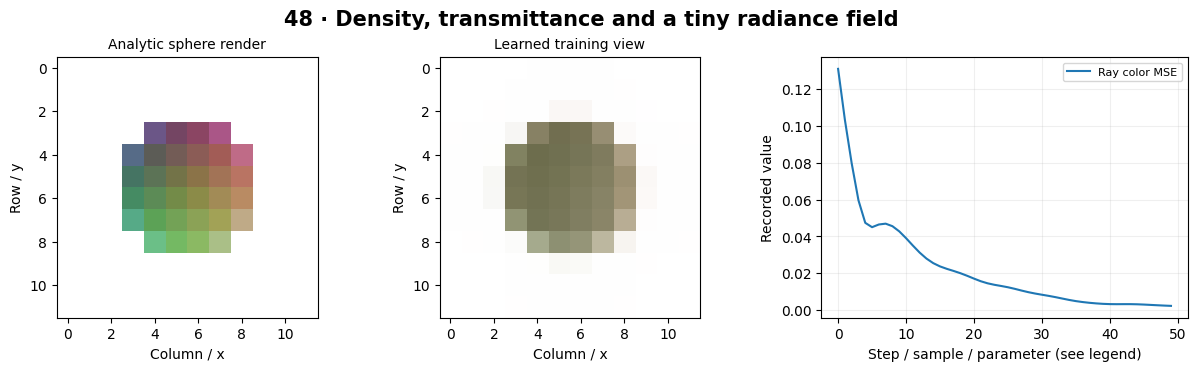

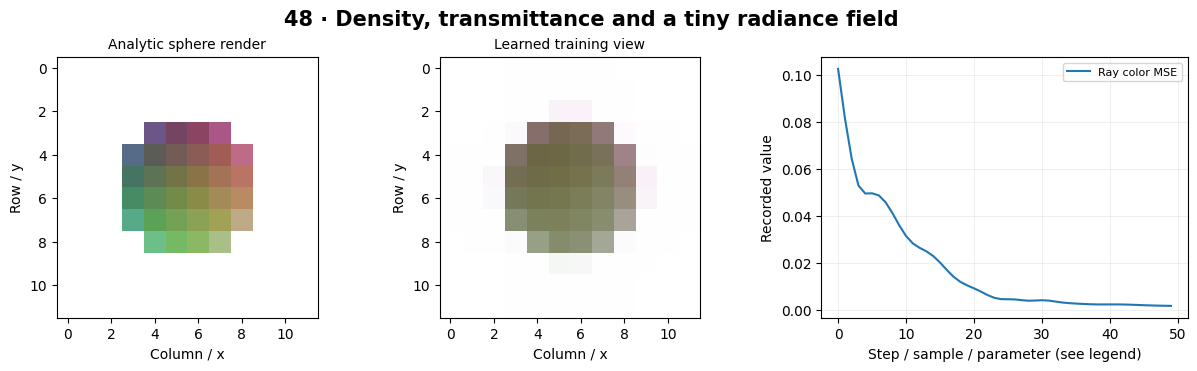

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Tiny NeRF Study**. Train a tiny synthetic scene and separate camera errors from model errors. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Low training-image loss does not prove correct 3D geometry. Ignoring background transmittance darkens empty rays.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Hold out a camera view in an extended multiview experiment and compare its error with training-view error. Inspect whether density is plausible or merely explains one view.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Extend the tiny field to several known cameras and evaluate an unseen view with fixed scene bounds and rendering settings.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A ray starts at a camera origin and advances along a direction. A network can map sampled positions and view directions to density and color. Positional encoding supplies sinusoidal features to represent spatial variation. The local model uses positions only, so it cannot model full view-dependent appearance.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Volume rendering and transmittance** in this chapter.

[Primary reference](https://arxiv.org/abs/2003.08934) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)